# Airline Dataset

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
df = pd.read_csv("airline_passenger_satisfaction.csv")
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

# Creating Stage 2 (In-Flight Features Only)

In [4]:
stage2_columns = [
    'Departure and Arrival Time Convenience',
    'Departure Delay',
    'On-board Service',
    'Seat Comfort',
    'Leg Room Service',
    'Cleanliness',
    'Food and Drink',
    'In-flight Service',
    'In-flight Wifi Service',
    'In-flight Entertainment',
    'Baggage Handling',
    'Satisfaction'
]

df_stage2 = df[stage2_columns].copy()
df_stage2.head()


,Departure and Arrival Time Convenience,Departure Delay,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,3,2,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,26,5,4,5,5,3,5,2,5,5,Satisfied
2,4,0,3,5,3,5,5,3,4,3,3,Satisfied
3,2,0,5,5,5,4,4,5,2,5,5,Satisfied
4,3,0,3,4,4,5,4,3,3,3,3,Satisfied


In [5]:
# ==========================================
# Stage-2 Feature Selection Justification
# ==========================================

# Stage-2 features represent onboard and cabin service experience factors
# encountered after the passenger boards the aircraft.
#
# These variables measure service quality attributes such as seating comfort,
# in-flight entertainment, food and beverage quality, WiFi performance,
# cleanliness, and crew service responsiveness.
#
# Pre-flight demographic variables and airport experience features are
# intentionally excluded to maintain stage independence and prevent
# cross-stage information overlap.
#
# This design allows the Stage-2 model to isolate the incremental impact
# of in-flight service quality on passenger satisfaction.

# Analyzing Data Types

In [5]:
df_stage2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 12 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   Departure and Arrival Time Convenience  129880 non-null  int64 
 1   Departure Delay                         129880 non-null  int64 
 2   On-board Service                        129880 non-null  int64 
 3   Seat Comfort                            129880 non-null  int64 
 4   Leg Room Service                        129880 non-null  int64 
 5   Cleanliness                             129880 non-null  int64 
 6   Food and Drink                          129880 non-null  int64 
 7   In-flight Service                       129880 non-null  int64 
 8   In-flight Wifi Service                  129880 non-null  int64 
 9   In-flight Entertainment                 129880 non-null  int64 
 10  Baggage Handling                        129880 non-null 

In [6]:
num_cols=df_stage2.select_dtypes(include='number').columns
print('Numerical Columns :\n',num_cols)

Category_Columns=df_stage2.select_dtypes(include='object').columns
print('\n Categorical Columns :\n',Category_Columns)

Numerical Columns :
 Index(['Departure and Arrival Time Convenience', 'Departure Delay',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling'],
      dtype='object')

 Categorical Columns :
 Index(['Satisfaction'], dtype='object')


# Checking Missing value

In [7]:
df_stage2.isna().sum()

Departure and Arrival Time Convenience    0
Departure Delay                           0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                          0
Satisfaction                              0
dtype: int64

# Summary Statistics

In [8]:
df_stage2.describe()

,Departure and Arrival Time Convenience,Departure Delay,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,3.057599,14.713713,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,1.526741,38.071126,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,3.000000,0.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,4.000000,12.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,5.000000,1592.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# Distribution of Each Service Feature

In [9]:
for col in df_stage2.columns[:-1]:
    print(df_stage2[col].value_counts(normalize=True))
    print("------------")

Departure and Arrival Time Convenience
4    0.245457
5    0.215568
3    0.172298
2    0.165799
1    0.149438
0    0.051440
Name: proportion, dtype: float64
------------
Departure Delay
0      0.564798
1      0.028349
2      0.021982
3      0.019518
4      0.017778
         ...   
921    0.000008
581    0.000008
345    0.000008
463    0.000008
359    0.000008
Name: proportion, Length: 466, dtype: float64
------------
On-board Service
4    0.297990
5    0.227071
3    0.219757
2    0.141292
1    0.113851
0    0.000038
Name: proportion, dtype: float64
------------
Seat Comfort
4    0.306098
5    0.255297
3    0.179612
2    0.142662
1    0.116323
0    0.000008
Name: proportion, dtype: float64
------------
Leg Room Service
4    0.276301
5    0.237950
3    0.192917
2    0.188944
1    0.099284
0    0.004604
Name: proportion, dtype: float64
------------
Cleanliness
4    0.261541
3    0.235902
5    0.218787
2    0.154858
1    0.128804
0    0.000108
Name: proportion, dtype: float64
------------
F

# Target distribution

In [10]:
df_stage2['Satisfaction'].value_counts(normalize=True)

Satisfaction
Neutral or Dissatisfied    0.565537
Satisfied                  0.434463
Name: proportion, dtype: float64

# EDA

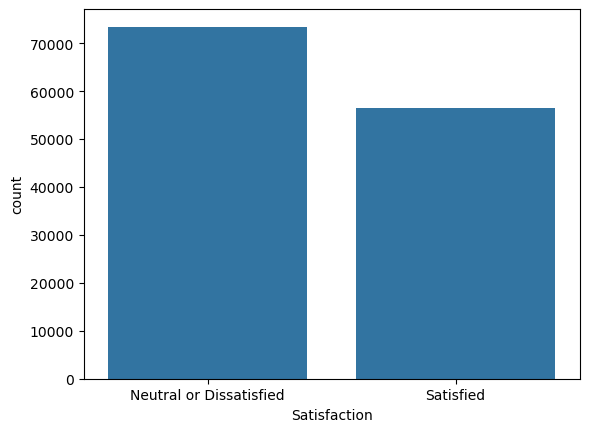

In [11]:
sns.countplot(x='Satisfaction', data=df_stage2)
plt.show()

<Axes: xlabel='Departure Delay', ylabel='Count'>

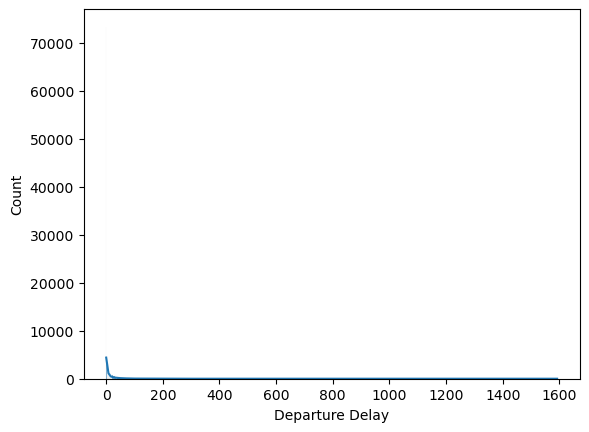

In [12]:
sns.histplot(df['Departure Delay'],kde=True)

# Analysis of In-Flight Features vs Passenger Satisfaction

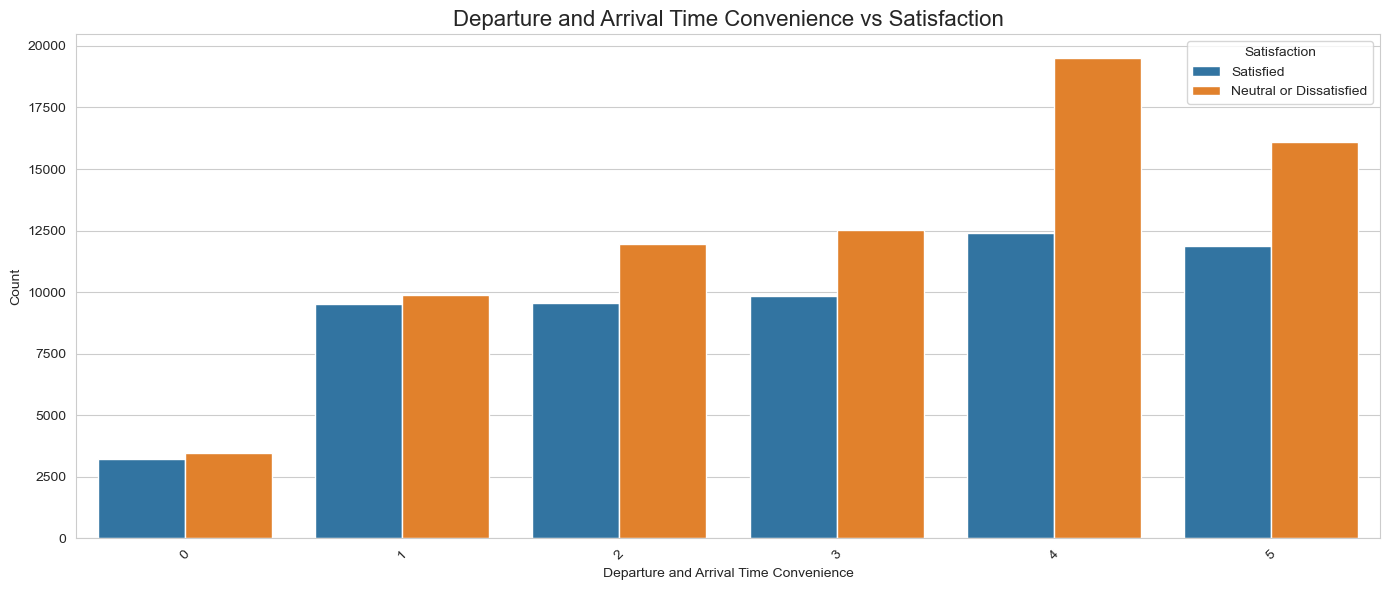

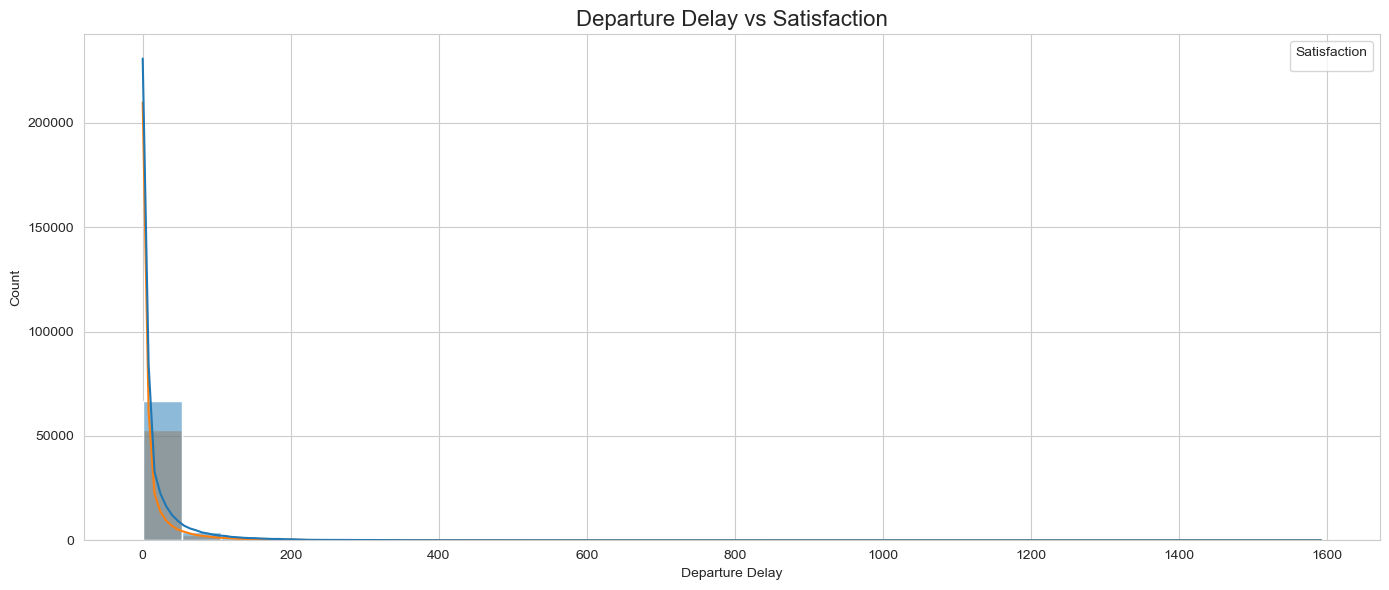

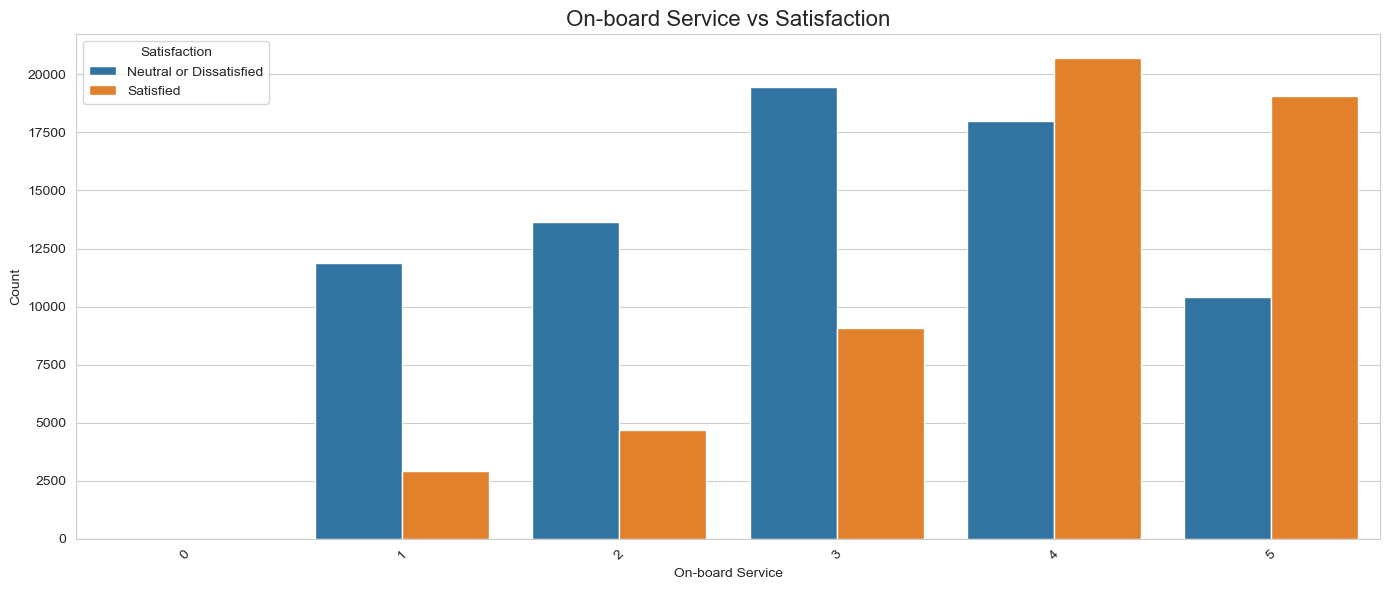

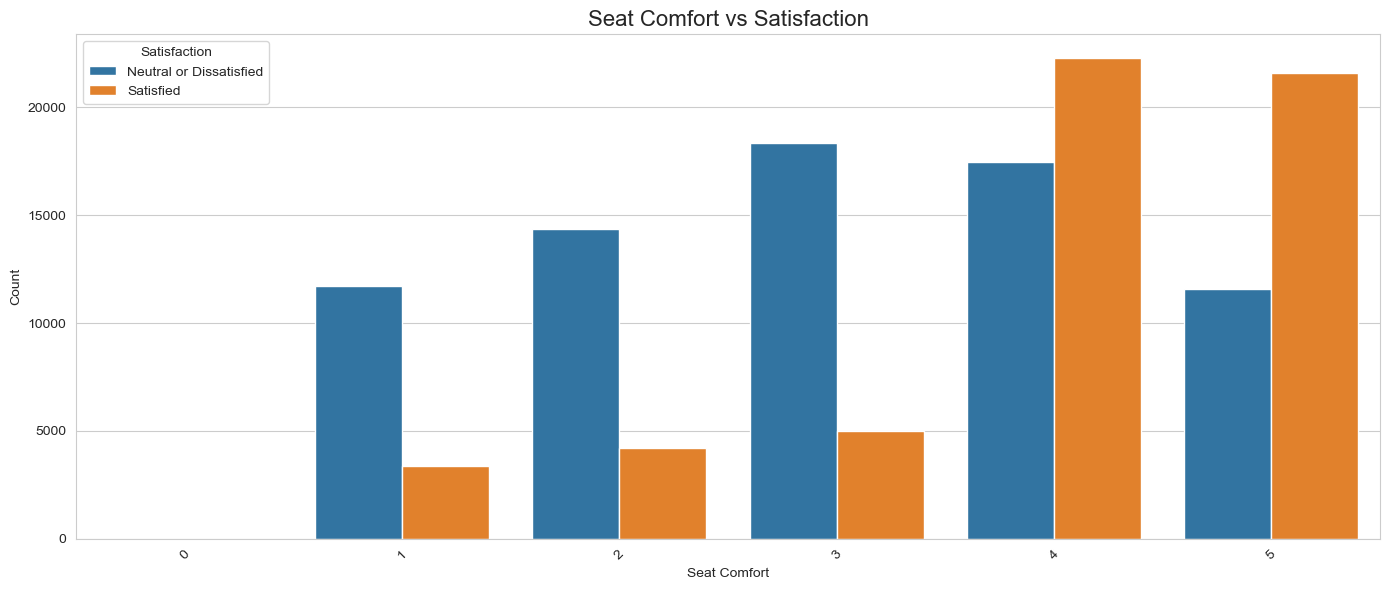

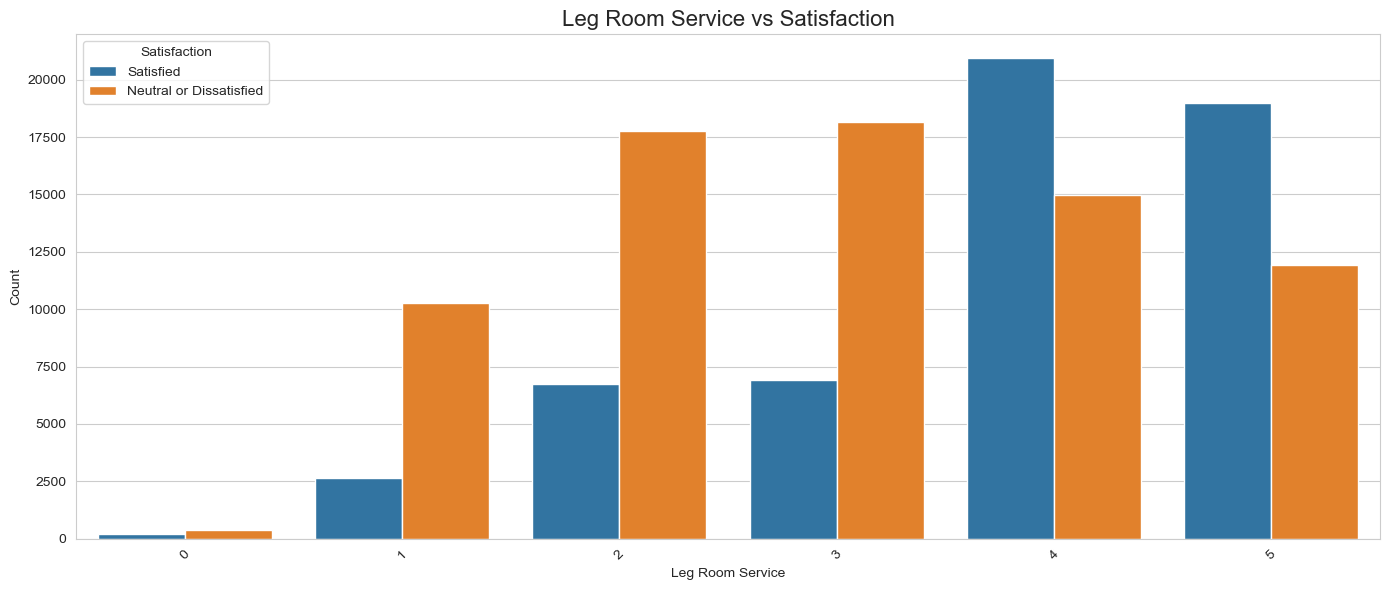

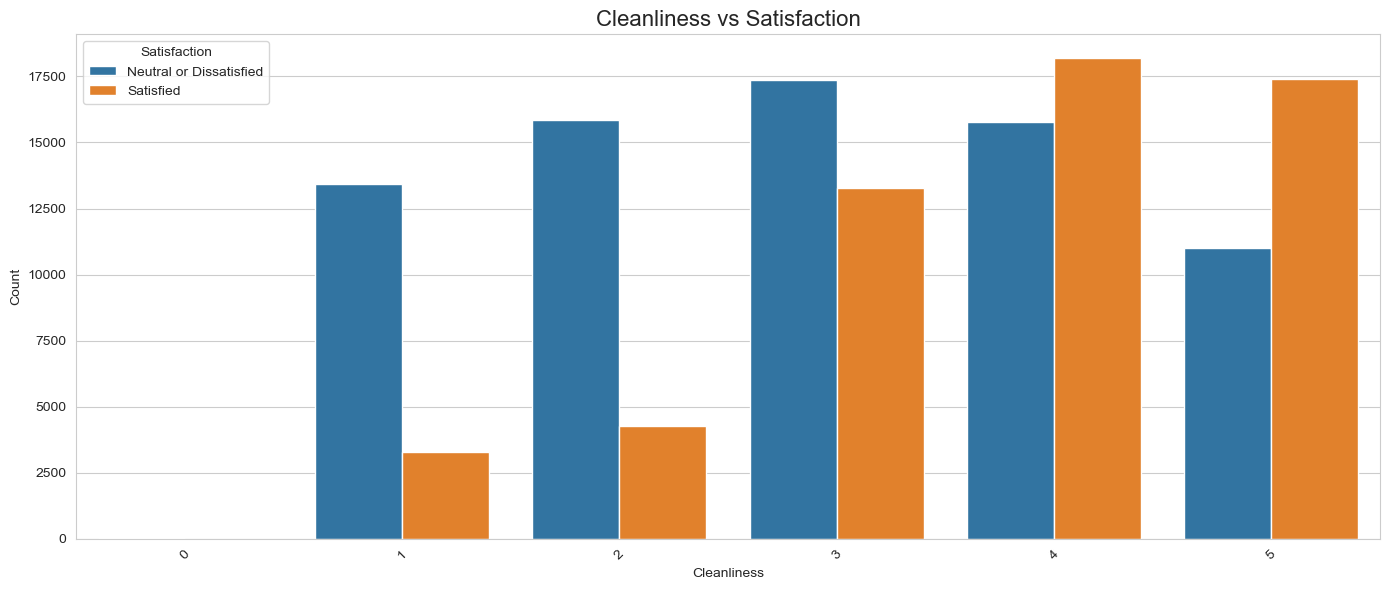

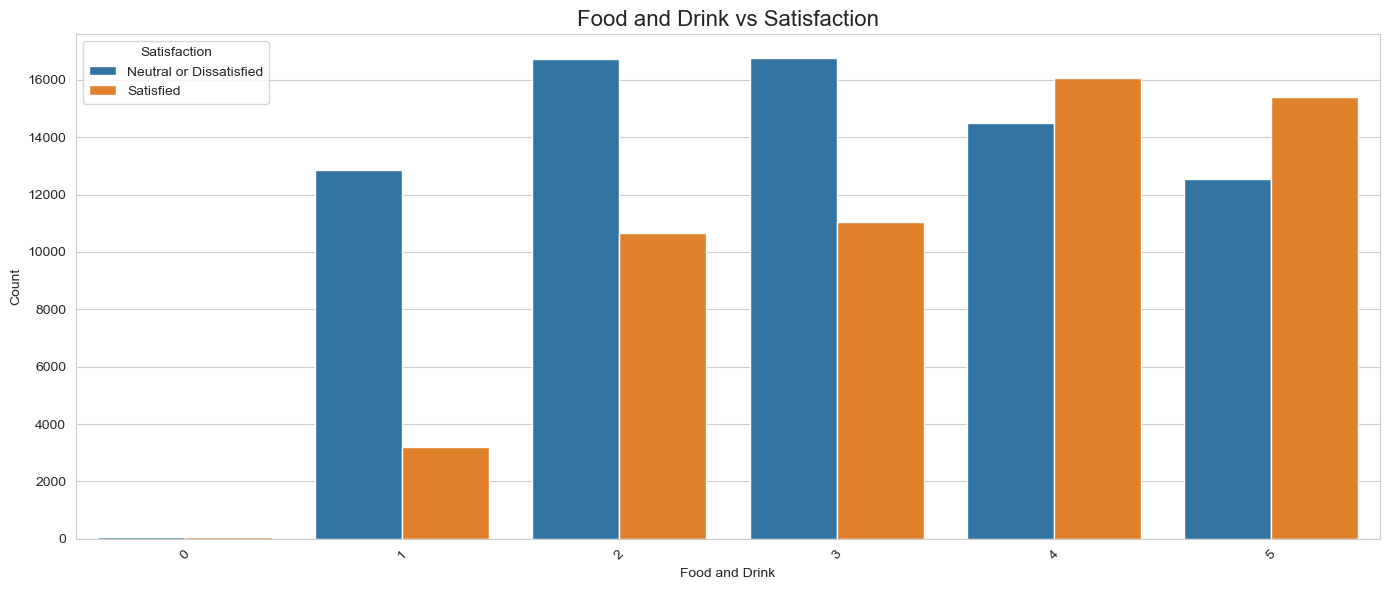

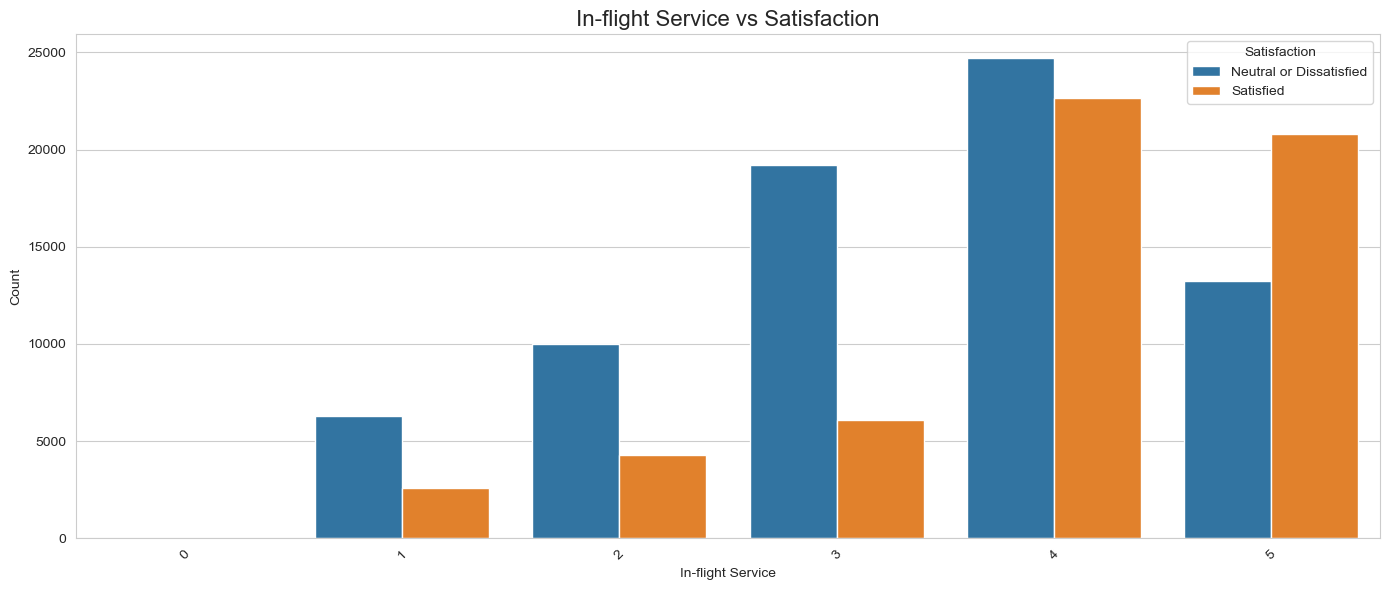

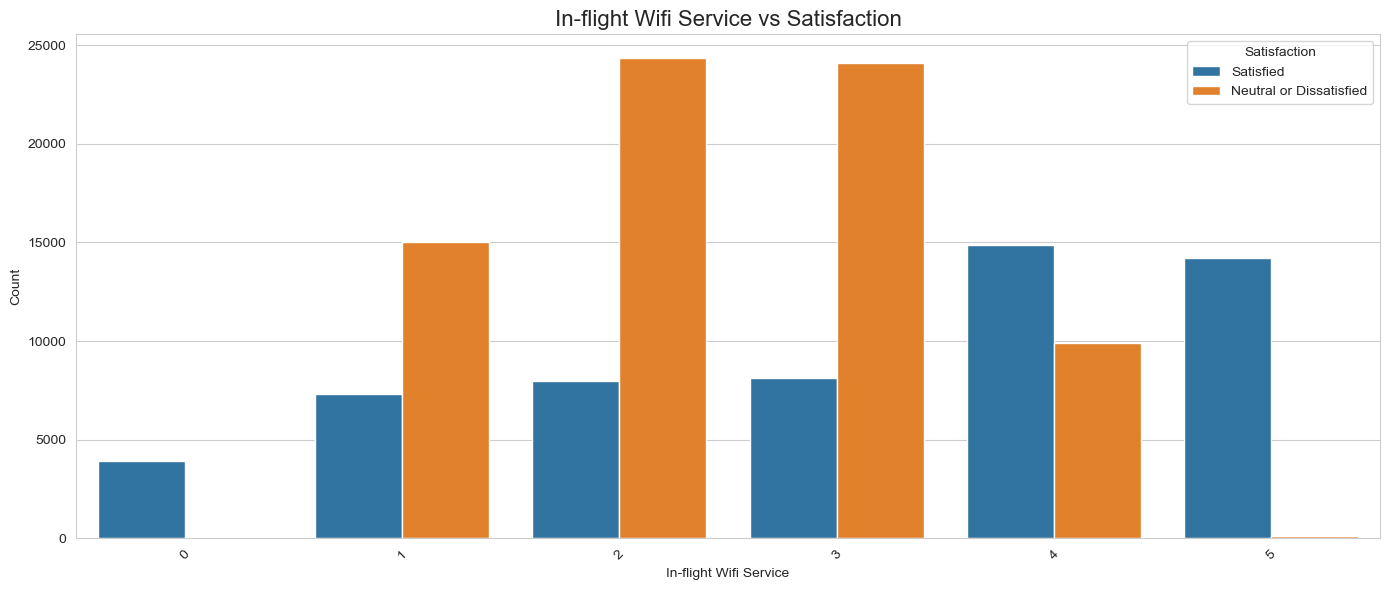

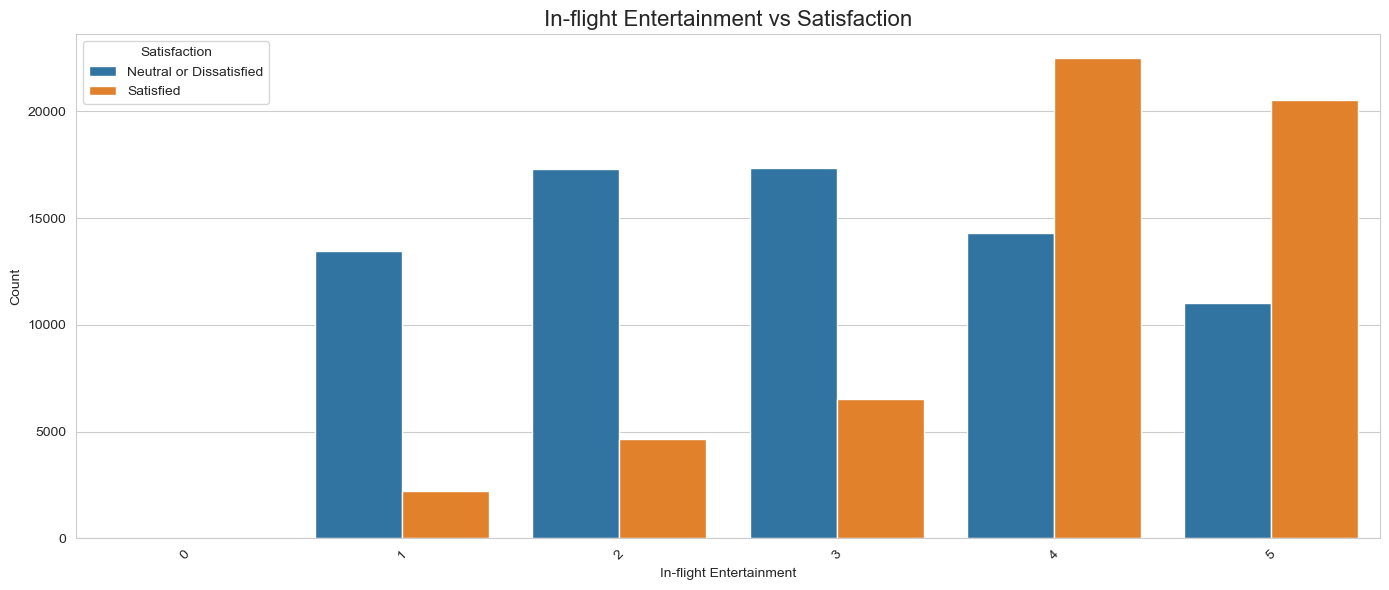

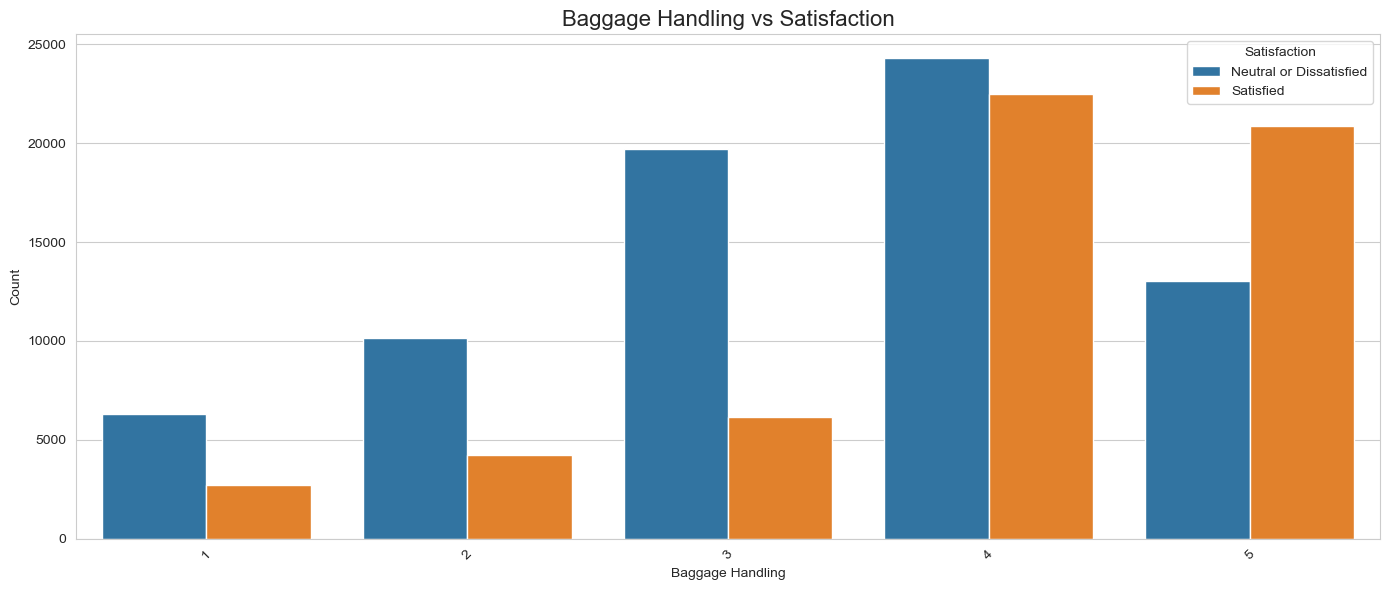

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

inflight_columns = [
    'Departure and Arrival Time Convenience', 
    'Departure Delay',  # continius numeric
    'On-board Service', 
    'Seat Comfort', 
    'Leg Room Service',
    'Cleanliness', 
    'Food and Drink', 
    'In-flight Service', 
    'In-flight Wifi Service', 
    'In-flight Entertainment', 
    'Baggage Handling'
]

for col in inflight_columns:
    plt.figure(figsize=(14,6))
    
    
    if df_stage2[col].nunique() > 15:  # continuous feature
        sns.histplot(data=df_stage2, x=col, hue='Satisfaction', bins=30, kde=True)
    else:  # categorical feature
        sns.countplot(x=col, hue='Satisfaction', data=df_stage2)
        plt.xticks(rotation=45)
    
    plt.title(f"{col} vs Satisfaction", fontsize=16)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Satisfaction")
    plt.tight_layout()
    plt.show()

# Skewness check

In [14]:
skewness = df_stage2[num_cols].skew()
print("Skewness of Numerical Features:")
print(skewness)

Skewness of Numerical Features:
Departure and Arrival Time Convenience   -0.332469
Departure Delay                           6.821980
On-board Service                         -0.421320
Seat Comfort                             -0.485818
Leg Room Service                         -0.348414
Cleanliness                              -0.300926
Food and Drink                           -0.155063
In-flight Service                        -0.691580
In-flight Wifi Service                    0.040465
In-flight Entertainment                  -0.366385
Baggage Handling                         -0.677400
dtype: float64


Between -0.5 and 0.5 → Fairly symmetric

Between 0.5 and 1 → Moderately skewed

Greater than 1 → Highly skewed

# Outliers Check

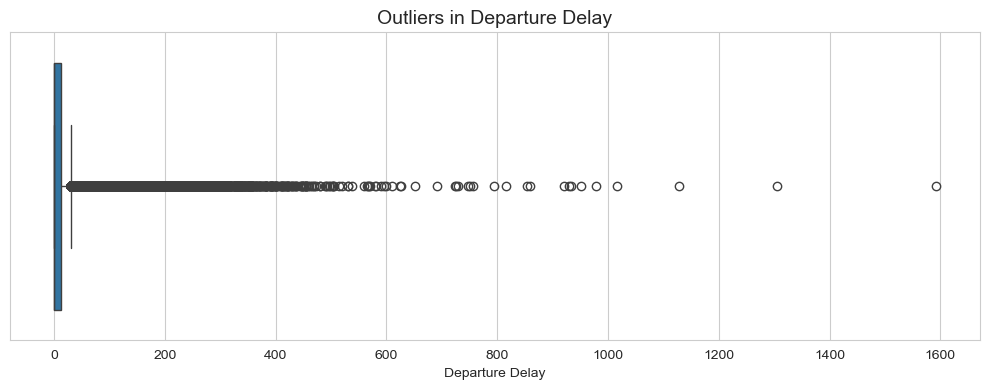

In [15]:
plt.figure(figsize=(10,4))
sns.boxplot(x='Departure Delay', data=df_stage2)

plt.title("Outliers in Departure Delay", fontsize=14)
plt.xlabel("Departure Delay")
plt.tight_layout()

plt.show()

In [16]:
Q1 = df_stage2['Departure Delay'].quantile(0.25)
Q3 = df_stage2['Departure Delay'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -18.0
Upper Bound: 30.0


In [17]:
for col in num_cols:
    Q1 = df_stage2[col].quantile(0.25)
    Q3 = df_stage2[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_stage2[(df_stage2[col] < lower_bound) | (df_stage2[col] > upper_bound)]
    
    print(f"{col}: {len(outliers)} outliers")

Departure and Arrival Time Convenience: 0 outliers
Departure Delay: 18098 outliers
On-board Service: 0 outliers
Seat Comfort: 0 outliers
Leg Room Service: 0 outliers
Cleanliness: 0 outliers
Food and Drink: 0 outliers
In-flight Service: 0 outliers
In-flight Wifi Service: 0 outliers
In-flight Entertainment: 0 outliers
Baggage Handling: 0 outliers


# Applying log trasformation

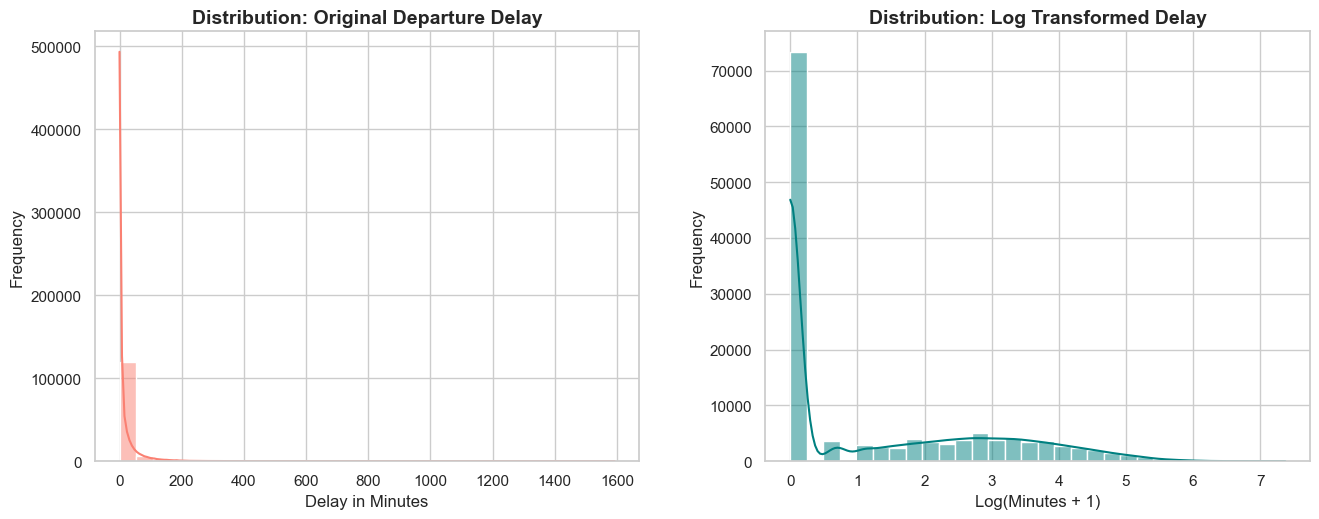

In [19]:
import numpy as np
df_stage2["Departure Delay_log"] = np.log1p(df_stage2["Departure Delay"])

sns.set_theme(style="whitegrid") 
plt.figure(figsize=(14, 6), dpi=100)

# BEFORE: Original Data
plt.subplot(1, 2, 1)
sns.histplot(df_stage2["Departure Delay"], kde=True, color="salmon", bins=30)
plt.title("Distribution: Original Departure Delay", fontsize=14, fontweight='bold')
plt.xlabel("Delay in Minutes")
plt.ylabel("Frequency")

# AFTER: Log Transformed
plt.subplot(1, 2, 2)
sns.histplot(df_stage2["Departure Delay_log"], kde=True, color="teal", bins=30)
plt.title("Distribution: Log Transformed Delay", fontsize=14, fontweight='bold')
plt.xlabel("Log(Minutes + 1)")
plt.ylabel("Frequency")

# 4. Final adjustments
plt.tight_layout(pad=3.0) 
plt.show()

# Correlation Heatmap 

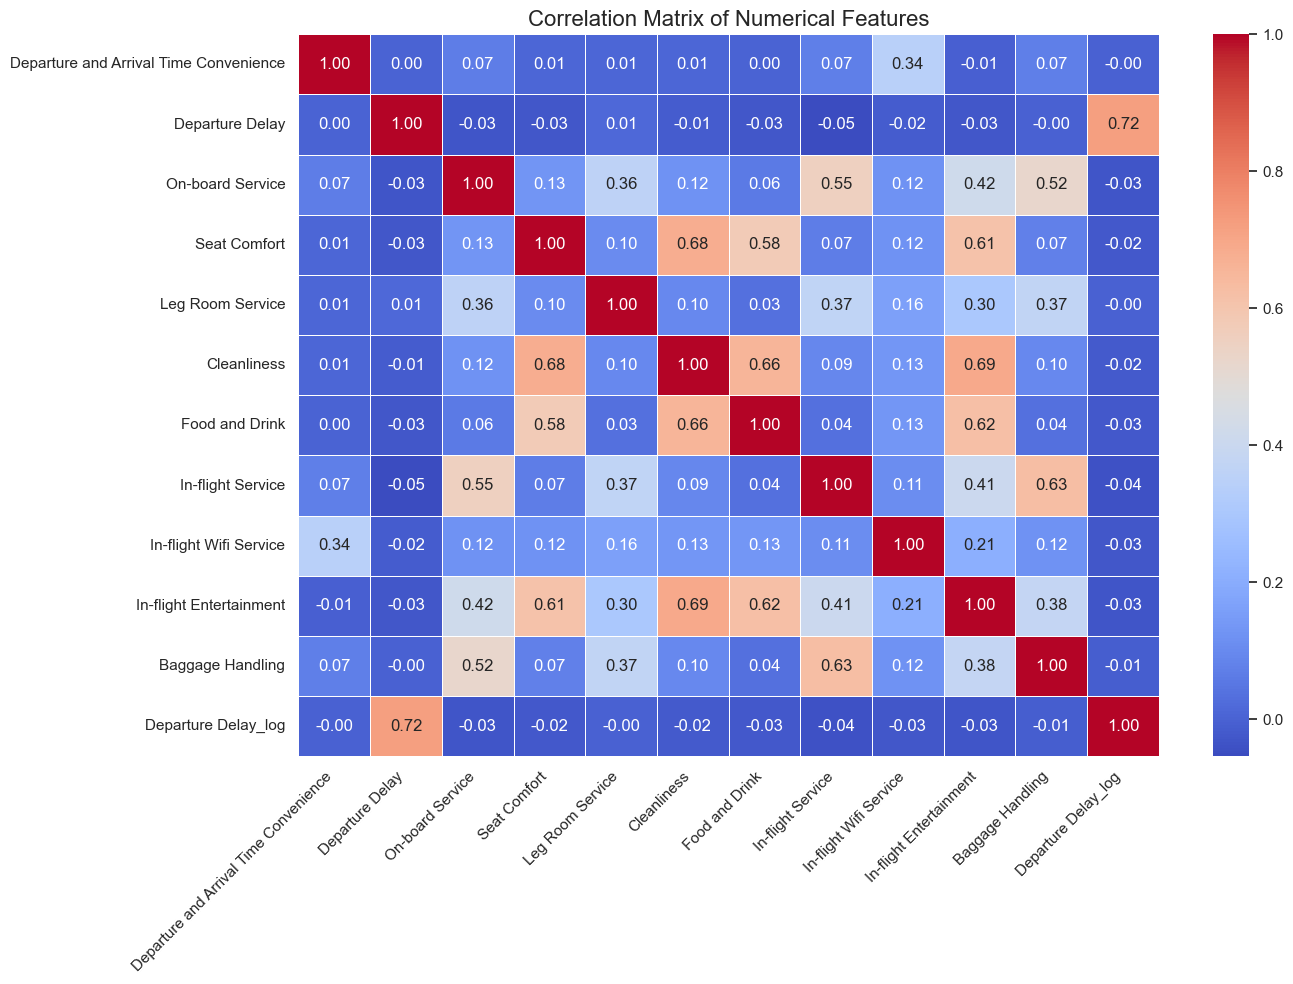

In [20]:
num_df = df_stage2.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(14,10))

sns.heatmap(
    num_df.corr(),
    annot=True,
    fmt=".2f",              
    cmap='coolwarm',
    linewidths=0.5,     
    cbar=True
)

plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Correlation Analysis Inference

The correlation matrix shows the relationships between different service-related features in the dataset.

Most features exhibit low to moderate correlation with each other, indicating that they provide unique and independent information to the model. This is beneficial for machine learning models as it reduces redundancy and improves predictive performance.

However, some features show relatively higher positive correlations:

- Seat Comfort and Cleanliness (~0.68)
- Cleanliness and In-flight Entertainment (~0.69)
- Food and Drink and Cleanliness (~0.66)
- In-flight Service and Baggage Handling (~0.63)
- Seat Comfort and In-flight Entertainment (~0.61)

These relationships suggest that passengers who rate one service highly are likely to rate related services highly as well, indicating consistency in customer experience.

On the other hand, features like Departure Delay show very low correlation with most service-related variables, suggesting that delays are relatively independent of in-flight service quality.

Overall, there is no evidence of extremely high correlation (above 0.9), which means multicollinearity is not a concern in this dataset. Therefore, all features can be retained for model training without the need for dimensionality reduction techniques like PCA.

This balanced correlation structure helps models like Random Forest perform effectively by leveraging diverse and complementary features.

# Encoding, preprocessing 

In [36]:
X = df_stage2.drop("Satisfaction", axis=1).copy()
y = df_stage2["Satisfaction"]

# FEATURE ENGINEERING
X['Departure Delay_log'] = np.log1p(X['Departure Delay'])
X = X.drop('Departure Delay', axis=1)

# ENCODEING TARGET VARIABLE
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Train-Test Split

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

# Logistic Regression (Baseline Model)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000,random_state=42))
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

# Evaluation Metrics

In [41]:
from sklearn.metrics import classification_report, recall_score,accuracy_score

y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))

recall_lr = recall_score(y_test, y_pred_lr, pos_label=0)
print("Recall for class 0 (LR):", recall_lr)

Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.79      0.81      0.80     14690
           1       0.74      0.72      0.73     11286

    accuracy                           0.77     25976
   macro avg       0.77      0.77      0.77     25976
weighted avg       0.77      0.77      0.77     25976

Recall for class 0 (LR): 0.8085772634445201


# MODEL BENCHMARKING

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC

In [53]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),
    "SVM": LinearSVC(class_weight='balanced'),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss',random_state=42)
}

for name, model in models.items():
    
    # Only scale for models that need it
    if name in ["Logistic Regression", "SVM"]:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
    else:
        pipe = Pipeline([
            ('model', model)
        ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred,pos_label=0))


Logistic Regression
Accuracy: 0.7721358176778564
Recall: 0.8085772634445201

Decision Tree
Accuracy: 0.8892439174622728
Recall: 0.9080326752893124

Random Forest
Accuracy: 0.908338466276563
Recall: 0.9327433628318584

SVM
Accuracy: 0.7587388358484756
Recall: 0.7385296119809394

AdaBoost
Accuracy: 0.8426624576532183
Recall: 0.8933287950987066

XGBoost
Accuracy: 0.9180012319063752
Recall: 0.9372362151123214


Decision Tree → simple, interpretable baseline tree model

AdaBoost → boosting model (focuses on correcting errors)

Random Forest → bagging model (reduces variance)

XGBoost → advanced boosting (usually top performer)

In [54]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Recall"])
results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Recall
5,XGBoost,0.918001,0.937236
2,RandomForest,0.908338,0.932743
1,DecisionTree,0.888628,0.893941
4,AdaBoost,0.842662,0.893329
0,Logistic,0.772290,0.808645
3,SVM,0.758739,0.738530


# Final Model Selection

In [59]:
Xgb_pipeline = Pipeline([
    ('model', XGBClassifier(use_label_encoder=False,eval_metric='logloss', random_state=42))
])

Xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

# Final Evaluation

In [60]:
y_pred_Xgb = Xgb_pipeline.predict(X_test)

print("\nXGBoost Report:\n")
print(classification_report(y_test, y_pred_Xgb))

recall_Xgb = recall_score(y_test, y_pred_Xgb, pos_label=0)
print("Recall for class 0 (Xgb):", recall_Xgb)


XGBoost Report:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93     14690
           1       0.92      0.89      0.90     11286

    accuracy                           0.92     25976
   macro avg       0.92      0.92      0.92     25976
weighted avg       0.92      0.92      0.92     25976

Recall for class 0 (Xgb): 0.9372362151123214


# XGBoost Model Inference

The XGBoost model achieved an overall accuracy of 92%, indicating strong predictive performance and slightly better results compared to many baseline models.

The model shows a recall of 93.7% for class 0 (dissatisfied customers), which means it is highly effective at correctly identifying dissatisfied passengers. This is crucial for the business objective, as it ensures that most unhappy customers are captured and can be addressed to improve customer satisfaction and retention.

At the same time, the model maintains a recall of 89% for satisfied customers, showing that it performs well across both classes without heavily favoring one class over the other.

# Confusion Matrix

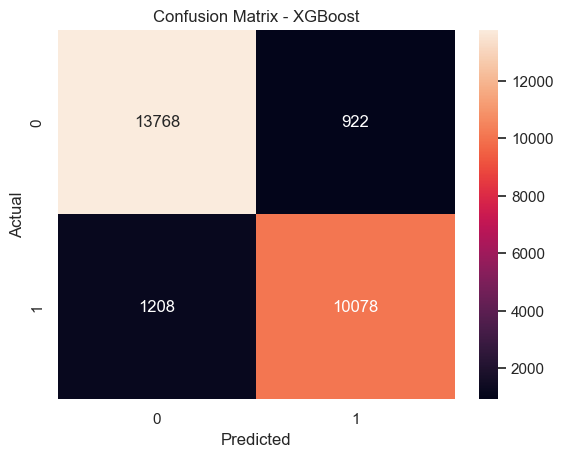

In [62]:
from sklearn.metrics import confusion_matrix

y_pred_Xgb =Xgb_pipeline.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_Xgb)

# Plot
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

The model demonstrates robust classification performance with a high concentration of correct predictions ( for 13768 Class 0 and 10078 for Class 1) along the diagonal.  The low error rates and balanced performance across both classes confirm the model is highly reliable and accurate for our project.

# Roc-Auc Score

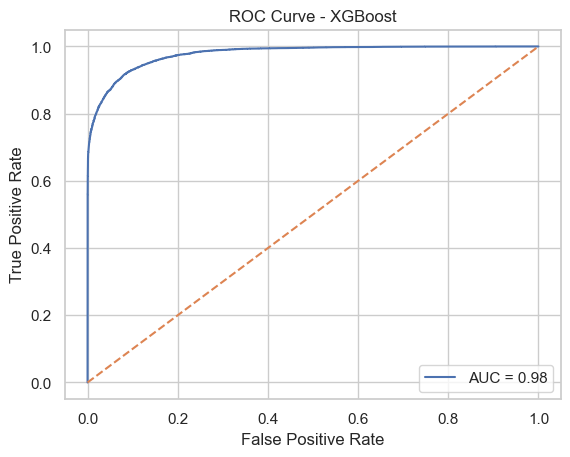

In [63]:
from sklearn.metrics import roc_curve, auc

# Probabilities
y_prob_Xgb = Xgb_pipeline.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_Xgb)
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

# Feature Importance

In [64]:
model = Xgb_pipeline.named_steps['model']

In [65]:
feature_names = X.columns
importances = model.feature_importances_

In [66]:
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
7,In-flight Wifi Service,0.296743
8,In-flight Entertainment,0.228359
3,Leg Room Service,0.114100
0,Departure and Arrival Time Convenience,0.086961
1,On-board Service,0.070550
2,Seat Comfort,0.069181
4,Cleanliness,0.046761
9,Baggage Handling,0.033064
6,In-flight Service,0.028334
5,Food and Drink,0.017692


### Inference 
The most influential feature is In-flight Wifi Service (29%), indicating that internet connectivity plays a critical role in passenger experience. Poor Wi-Fi service significantly increases the likelihood of passenger dissatisfaction, especially for business travelers who rely on connectivity during flights.

In-flight Entertainment (22%) also shows a high contribution, highlighting that passengers value entertainment options during longer journeys.

Leg Room Service (11%), suggesting that passenger comfort and space availability strongly affect satisfaction levels during the flight.


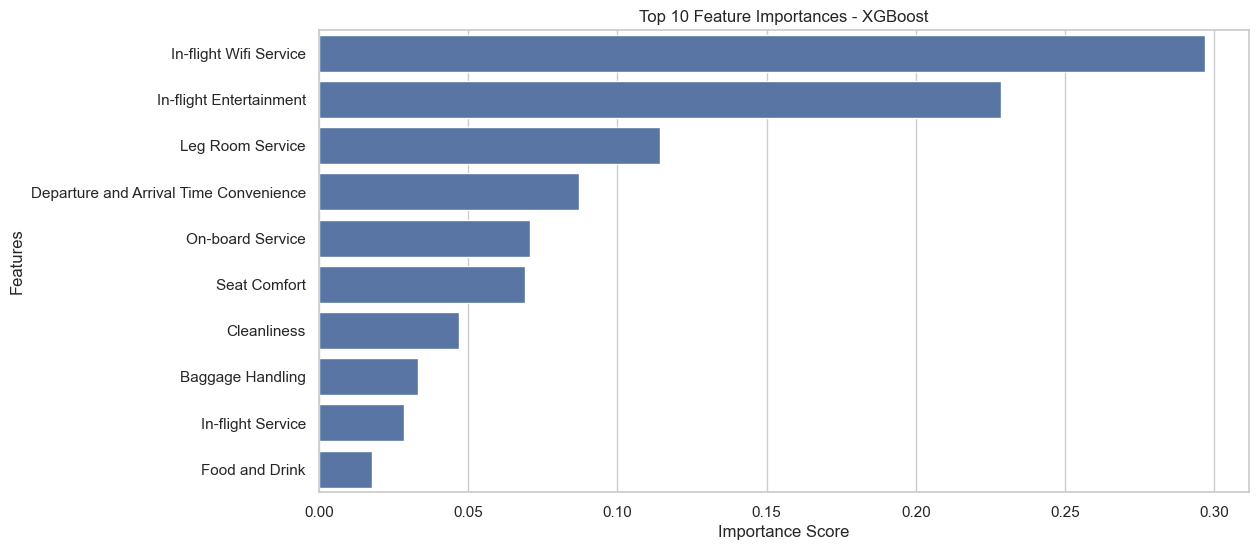

In [71]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance_df.head(10),  # Top 10 features
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# Business Interpretation 
## Business Insights

️1.In-flight Wifi Service is the most influential factor affecting passenger satisfaction. This suggests that reliable internet connectivity during the flight plays a major role in shaping the passenger experience.

2.️In-flight Entertainment also has a strong impact, indicating that passengers value access to entertainment options during the flight.

️3.Passenger comfort factors such as Leg Room Service and Seat Comfort are highly important, showing that physical comfort significantly contributes to overall satisfaction.

4.Departure and Arrival Time Convenience also influences satisfaction, which indicates that passengers value convenient flight schedules and punctual operations.

5.Operational service features such as On-board Service, Baggage Handling, and In-flight Service have moderate influence, suggesting that overall service quality still plays an important role in the passenger experience.

6.Food and Drink and Cleanliness show relatively lower importance, indicating that while they contribute to satisfaction, they are not the primary drivers compared to connectivity, entertainment, and comfort.

### The analysis shows that passenger satisfaction is primarily driven by in-flight connectivity, entertainment, and seating comfort. Airlines aiming to improve customer satisfaction should focus on enhancing onboard digital services, passenger comfort, and convenient flight schedules.

# KMeans + PCA = Unsupervised (Exploration)

In [72]:
#STEP 1: PREPARE DATA
X_cluster = df_stage2.drop("Satisfaction", axis=1)

In [73]:
from sklearn.compose import ColumnTransformer

num_cols = X_cluster.select_dtypes(include=['int64','float64']).columns
preprocessor_cluster = ColumnTransformer([
    ("num", StandardScaler(), num_cols)
])

X_cluster_transformed = preprocessor_cluster.fit_transform(X_cluster)

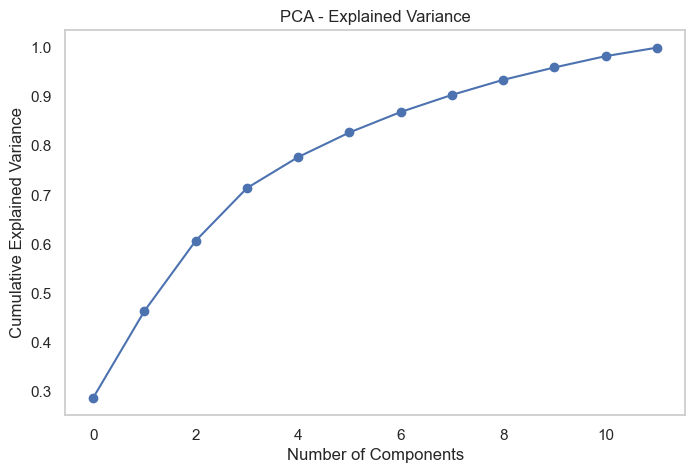

In [74]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_cluster_transformed)

plt.figure(figsize=(8,5))
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.grid()
plt.show()


In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [76]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.31252944 0.19284017]


## PCA 

PCA was applied to reduce dimensionality and analyze variance distribution among features. Although the dataset has a relatively small number of features, PCA helps in understanding feature contribution and visualizing the data in reduced dimensions.

However, since all features are meaningful service ratings and there is no high multicollinearity, PCA was not used in the final model to preserve interpretability.

# Elbow Method

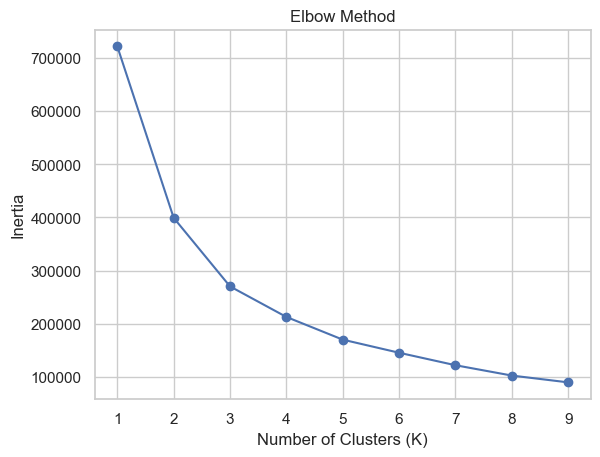

In [77]:
from sklearn.cluster import KMeans
inertia = []

K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

# Plot
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Silhouette Score

In [78]:
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.408
K = 3, Silhouette Score = 0.411
K = 4, Silhouette Score = 0.359
K = 5, Silhouette Score = 0.359
K = 6, Silhouette Score = 0.357
K = 7, Silhouette Score = 0.366
K = 8, Silhouette Score = 0.377
K = 9, Silhouette Score = 0.395


# Final K-Means

In [79]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Add to dataframe
df_stage2['Cluster'] = clusters

# Visualization

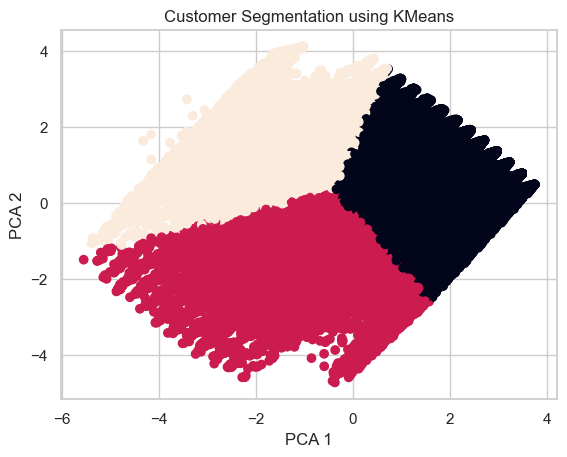

In [80]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segmentation using KMeans")
plt.show()

## K-Means Clustering Inference

K-Means clustering was applied to segment customers based on their service ratings. The optimal number of clusters was determined as 3 using the elbow method and silhouette score, indicating well-defined and meaningful groupings in the data.

The three clusters represent distinct customer segments:

- Cluster 0: Customers with high service ratings, indicating high satisfaction levels.
- Cluster 1: Customers with moderate ratings, representing neutral or average satisfaction.
- Cluster 2: Customers with low ratings, indicating dissatisfied customers.

This clustering pattern aligns with the nature of the dataset, where customer satisfaction can naturally be grouped into low, medium, and high categories.

The results show that customer experiences are not randomly distributed but follow clear patterns, which can be effectively captured using clustering techniques.

## Business Insights

- The dissatisfied cluster (low ratings) can be targeted for service improvement and retention strategies.
- The neutral cluster can be converted into satisfied customers through targeted enhancements.
- The satisfied cluster represents loyal customers and can be leveraged for brand advocacy.

Overall, K-Means clustering provides valuable segmentation insights that complement the predictive model and help in better decision-making.